In [15]:
# 1) Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Import libraries
import os
import zipfile
import numpy as np
import pandas as pd
from glob import glob

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# 3) Folder and file names
DRIVE_FOLDER = "/content/drive/MyDrive/PINN CNN Dataset"
CSV_FILE = os.path.join(DRIVE_FOLDER, "dataset.csv")
ZIP_FILE = os.path.join(DRIVE_FOLDER, "images.zip")


In [28]:
# 4) Choose which property to predict
TARGET_COLUMN = "sigma_x_MPa"

In [18]:
# 5) Basic settings
IMG_SIZE = 64
EPOCHS = 10
BATCH_SIZE = 16

In [19]:
# 6) Extract images from zip file
EXTRACT_FOLDER = "/content/cfrp_images"
os.makedirs(EXTRACT_FOLDER, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_FOLDER)

print("Images extracted")

Images extracted


In [20]:
# 7) Load dataset.csv
df = pd.read_csv(CSV_FILE)
print("CSV loaded")
print(df.head())


CSV loaded
       image      E1_GPa     E2_GPa   G12_GPa      nu12  FiberVol_pct  \
0  img_0.png  126.832124  12.397813  5.434346  0.262292     63.941407   
1  img_1.png  121.432684   9.635225  5.566470  0.304174     53.741408   
2  img_2.png  148.780973  12.154258  6.927469  0.267926     50.855459   
3  img_3.png  149.106853   8.089365  5.559182  0.284889     54.170659   
4  img_4.png  149.282471   8.954079  4.249998  0.333680     56.459529   

   Orientation_deg  sigma_x_MPa  sigma_y_MPa  tau_xy_MPa     eps_x     eps_y  \
0        71.297823   451.795033    29.678507    5.782387  0.003562  0.002394   
1        85.183940   356.323945    21.915825    6.073504  0.002934  0.002275   
2        58.007834   328.596042    24.441353   23.078739  0.002209  0.002011   
3        31.743490   481.841842    14.749028    8.547255  0.003232  0.001823   
4        60.731243   389.846523    12.507645    6.959058  0.002611  0.001397   

   gamma_xy  
0  0.001064  
1  0.001091  
2  0.003331  
3  0.001538  

In [21]:
# 8) Find all png image files
image_files = glob(EXTRACT_FOLDER + "/**/*.png", recursive=True)
image_map = {os.path.basename(path): path for path in image_files}


In [24]:
# 9) Match each row with its real image file
def get_image_path(row):
    file_name = os.path.basename(str(row["image"]))
    return image_map.get(file_name)

df["full_image_path"] = df.apply(get_image_path, axis=1)
df = df.dropna(subset=["full_image_path"])

print("Usable rows:", len(df))

Usable rows: 200


In [26]:
# 10) Split data into train, validation, test
from sklearn.model_selection import train_test_split

# Split df into training (70%) and a temporary set (30%) for validation and test
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# Split the temporary set into validation (15%) and test (15%)
# Since temp_df is 30% of original, test_size=0.5 means 15% of original for validation and 15% for test
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("Test rows:", len(test_df))

Train rows: 140
Val rows: 30
Test rows: 30


In [29]:
# 11) Load images and target values into arrays
def load_data(data):
    X = []
    y = []

    for path, target in zip(data["full_image_path"], data[TARGET_COLUMN]):
        img = load_img(path, color_mode="grayscale", target_size=(IMG_SIZE, IMG_SIZE))
        img = img_to_array(img) / 255.0
        X.append(img)
        y.append(target)

    return np.array(X), np.array(y, dtype="float32")

X_train, y_train = load_data(train_df)
X_val, y_val = load_data(val_df)
X_test, y_test = load_data(test_df)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (140, 64, 64, 1)
Val shape: (30, 64, 64, 1)
Test shape: (30, 64, 64, 1)


In [30]:
# 12) Build simple CNN model
model = Sequential([
    Conv2D(16, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(32, activation="relu"),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       200,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 616,709 (2.35 MB)

 Trainable params: 205,569 (803.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 411,140 (1.57 MB)

In [32]:
# 13) Compile model
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# 14) Train model
model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 172402.1406 - mae: 406.1844 - val_loss: 155088.0625 - val_mae: 384.3540
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 153261.5781 - mae: 381.6212 - val_loss: 119301.1094 - val_mae: 334.7357
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 96587.4453 - mae: 295.3665 - val_loss: 41668.2148 - val_mae: 183.0583
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 22726.0371 - mae: 125.8502 - val_loss: 24353.9961 - val_mae: 129.6775
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 22601.8770 - mae: 117.5466 - val_loss: 13236.8574 - val_mae: 86.2562
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 12461.7021 - mae: 92.9630 - val_loss: 12056.9355 - val_mae: 86.1444
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 13070.7979 - mae: 95.3862 - val_loss: 10627.4004 - val_mae: 76.7619
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 11550.4355 - mae: 85.6993 - val_loss: 11407.5742 - val_

In [33]:
# 15) Predict on test data
y_pred = model.predict(X_test).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


In [34]:
# 16) Show results
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nPrediction target:", TARGET_COLUMN)
print("MAE  =", mae)
print("RMSE =", rmse)
print("R2   =", r2)


Prediction target: sigma_x_MPa
MAE  = 80.6567153930664
RMSE = 101.97722536031023
R2   = -0.7273612022399902


In [37]:
# 17) Save prediction table
result = pd.DataFrame({
    "sample_id": test_df["image"].values,
    "actual": y_test,
    "predicted": y_pred
})

print("\nSample results:")
print(result.head())


Sample results:
     sample_id      actual   predicted
0   img_95.png  388.792633  397.494446
1  img_115.png  411.379639  370.041809
2  img_135.png  415.463654  363.296600
3  img_195.png  413.307709  409.048462
4   img_78.png  489.205292  393.004944


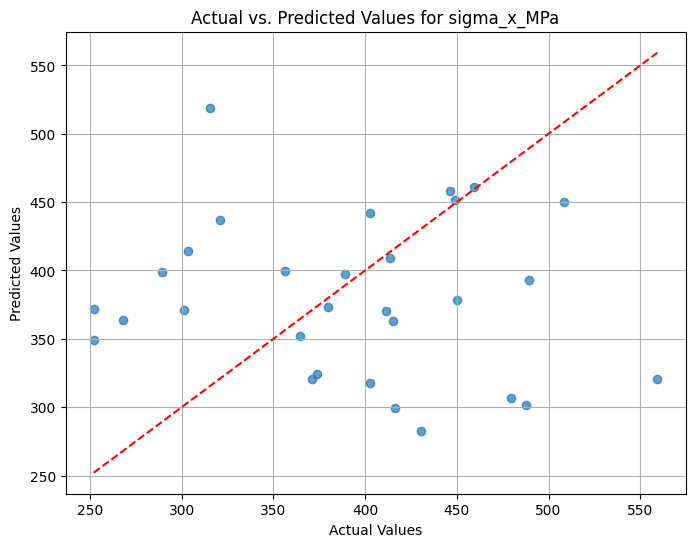

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--') # Diagonal line for perfect prediction
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs. Predicted Values for {TARGET_COLUMN}")
plt.grid(True)
plt.show()

In [41]:
# The loss function used for compiling the model is 'mse' (Mean Squared Error).
print(f"Loss function: {model.loss}")

Loss function: mse


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 10195.0654 - mae: 82.1445 - val_loss: 9851.0947 - val_mae: 75.8900
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 9741.5752 - mae: 79.8375 - val_loss: 9555.8799 - val_mae: 75.0249
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 9538.9531 - mae: 79.0342 - val_loss: 9161.4980 - val_mae: 73.8212
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 9220.8301 - mae: 78.4845 - val_loss: 8977.3584 - val_mae: 73.4167
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 8993.3096 - mae: 77.1353 - val_loss: 9047.0664 - val_mae: 73.8133
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 8787.0371 - mae: 76.3230 - val_loss: 8572.7139 - val_mae: 72.3728
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 8638.9258 - mae: 76.7974 - val_loss: 8583.3271 - val_mae: 72.5882
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 8643.3525 - mae: 75.1080 - val_loss: 8636.2354 - val_mae: 72.9895
Epoch 9/10
9/9 

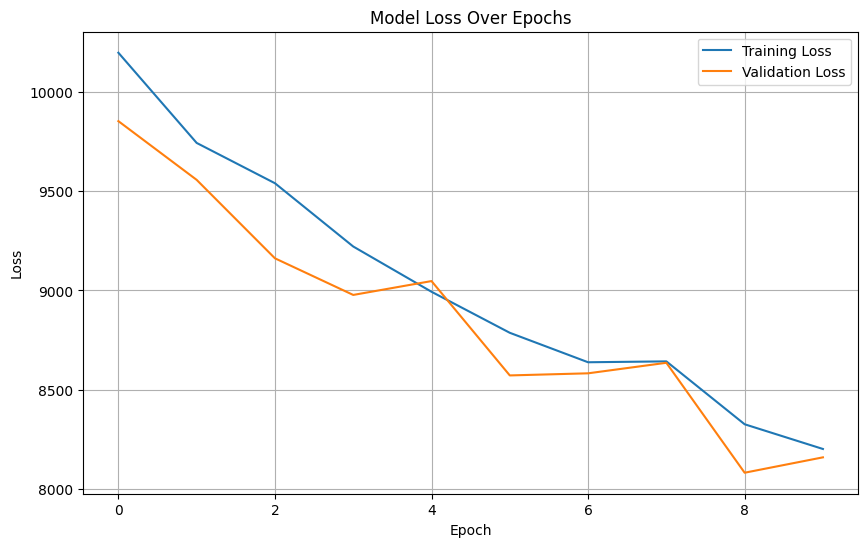

In [42]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
# 18) Save model and results into Google Drive
model.save(os.path.join(DRIVE_FOLDER, "easy_cfrp_model.h5"))
result.to_csv(os.path.join(DRIVE_FOLDER, "easy_cfrp_results.csv"), index=False)

print("\nModel and result file saved in Google Drive")


Model and result file saved in Google Drive
